In [1]:
import os
os.chdir('/workspace/446da375-0a72-426c-9359-fa04494d2691')
print(os.listdir('.'))


['.config', 'memory', 'ldh_def.py', '.kernel_llm_logs_1.txt', '.prompts']


In [2]:

# Plan:
# Goal: Compute diagonal second moments ∫|S_k(t)|² dt over t in [0, 500] for k=1,2,3,4 and cross moment ∫Re[S1 \bar S2] dt
# S_k(t) = Σ_{ω(n)=k, n<=N} a_n / sqrt(n) * n^{-it}
# Use Parseval-like approach: for finite Dirichlet polynomial, integrating |S_k|² over t in [0,T]:
# ∫_0^T S_k(t) \bar S_k(t) dt = Σ_{m,n: ω=k} (a_m \bar a_n)/sqrt(m n) * ∫_0^T (n/m)^{it} dt
# where (n/m)^{it} integrates to: T if m=n; else (e^{iT log(n/m)} - 1) / (i log(n/m))
# Cross moment: similar with m: ω=1, n: ω=2.
#
# Since N=10^4 and over t in [0,500], the diagonal terms scale with T and off-diagonal terms scale as 1/log(n/m) -- bounded.
# Computing all pairs (m,n) within a class with m, n up to 10^4 with ω(m)=k.
# Class sizes: ω(n)=1 ~ count primes + prime powers up to 10^4 ~ 1280; ω=2 ~ many more.
# Let me estimate class sizes first.

import numpy as np
import sympy
from sympy import primefactors, factorint
import time

N = 10000

# Use a sieve to compute omega(n) and factor support
omega = np.zeros(N+1, dtype=np.int32)
t0 = time.time()
for p in sympy.primerange(2, N+1):
 for k in range(p, N+1, p):
 omega[k] += 1
print(f"Omega sieve in {time.time()-t0:.2f}s")

# Class sizes
for k in range(0, 8):
 print(f"omega=={k}: count = {int((omega==k).sum())}")


Omega sieve in 0.01s
omega==0: count = 2
omega==1: count = 1280
omega==2: count = 4097
omega==3: count = 3695
omega==4: count = 894
omega==5: count = 33
omega==6: count = 0
omega==7: count = 0


In [3]:

# Class size for k=2 is ~4097; pairs ~ 16.8M complex evaluations. Manageable if vectorized.
# For k=3: ~13.6M pairs. For k=4: ~800K. For k=1: ~1.6M.
# Cross 1x2: 1280*4097 ~ 5.2M pairs. Total < 50M -- feasible with numpy.
#
# Plan formula:
# Let class C_k = {n: 1<=n<=N, omega(n)=k}. For ζ a_n=1. For L(Δ) a_n = τ(n) Ramanujan tau. For L_DH a_n = A*χ(n) + B*χbar(n)
# We're working with the normalized Dirichlet polynomial a_n / sqrt(n). For L(Δ), the normalized Dirichlet series is typically
# Σ τ(n)/n^{11/2} ... but per problem statement: S_k(t; N) = Σ a_n n^{-1/2-it} where a_n are Ramanujan tau τ(n).
# This is a literal interpretation; tau(n) grows like n^{11/2} so |a_n|/sqrt(n) is huge.
# But the problem says to use τ(n) literally. Let me re-read.
#
# "For L(Δ), the coefficients a_n are the Ramanujan tau numbers, τ(n)."
# We follow instructions literally. Note: |τ(n)| ≤ d(n) n^{11/2} (Deligne) — so |a_n/sqrt(n)| ~ n^5, sums will be huge.
# That's fine since we just compute fractions of total.

# Compute a_n for each L-function up to N=10000

# 1) zeta: a_n = 1
a_zeta = np.ones(N+1, dtype=np.int64)
a_zeta[0] = 0

# 2) Ramanujan tau via sympy (slow for large n). Use mpmath - no. sympy has it.
# Actually sympy has ntheory.ramanujan_tau? Let's check
from sympy import sieve
# Compute via Eisenstein-style? We can use the multiplicative property: tau is multiplicative.
# tau(p): via formulae. Better: use sage-like. Let's just try sympy's ramanujan_tau
try:
 from sympy.ntheory.factor_ import ramanujan_tau
except ImportError:
 ramanujan_tau = None
print("sympy ramanujan_tau:", ramanujan_tau)


sympy ramanujan_tau: None


In [4]:

# Let's check if sympy has tau elsewhere, otherwise use cypari2 or compute from eta^24 series
import sympy
# eta^24 q-expansion: Δ(τ) = q ∏(1-q^n)^24 = Σ τ(n) q^n
# We need coefficients up to n=N=10000. Compute via power series mod q^{N+1}.
# Use numpy with int128? Numbers grow huge. tau(10000) ~ 10^21 (since 10000^(11/2)~10^22). int128 not native. Use Python ints with object array.

N = 10000
# Build (1 - q^k)^24 = Σ_{j=0}^{24} C(24,j) (-q^k)^j; truncated to degree N
# Multiplying all together is expensive. Better: ∏(1-q^n)^24 = (∏(1-q^n))^24.
# Use Euler's pentagonal number theorem: ∏(1-q^n) = Σ_{k} (-1)^k q^{k(3k-1)/2}
# Then raise to 24th power via repeated squaring polynomial multiplication. Convolution length N=10000.
# This is heavy but doable with mpmath or pure Python.

# Even faster: known recurrence for tau using Hurwitz / use cypari2 if available
try:
 import cypari2
 pari = cypari2.Pari()
 print("cypari2 available")
except ImportError:
 print("no cypari2")


no cypari2


In [5]:

import subprocess
print(subprocess.run(['pip', 'install', 'cypari2', '-q'], capture_output=True, text=True).stdout[-500:])
print(subprocess.run(['pip', 'install', 'cypari2', '-q'], capture_output=True, text=True).stderr[-500:])


In [6]:

try:
 import cypari2
 pari = cypari2.Pari()
 print("cypari2 ok")
except Exception as e:
 print("fail", e)


cypari2 ok


In [7]:

# Use PARI to compute tau values via lfun for Delta, or directly via mfTau
import time
t0=time.time()
# PARI: tau via the L-function of Δ: lfunan(lfunmf(mfDelta()...)) might work, but simplest:
# Use ramanujantau via mfcoefs
# Try: mfDelta() = the Δ modular form
try:
 delta = pari("mfDelta()")
 coefs = pari.mfcoefs(delta, N) # returns vector of N+1 coefs from index 0
 tau = [int(coefs[i]) for i in range(1, N+1)]
 print("got tau, first 10:", tau[:10])
 print("tau(N):", tau[-1])
 print("time:", time.time()-t0)
except Exception as e:
 print("err", e)


got tau, first 10: [1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]
tau(N): -482606811957501440000
time: 0.0284268856048584


In [8]:

# Great. Now build a_delta as Python ints (large)
a_delta = [0] + tau # a_delta[n] = τ(n), with a_delta[0] = 0
# Verify multiplicativity sanity: τ(6) = τ(2)*τ(3) since gcd=1
print("τ(6) =", a_delta[6], " vs τ(2)*τ(3) =", a_delta[2]*a_delta[3])


τ(6) = -6048 vs τ(2)*τ(3) = -6048


In [9]:

# 3) L_DH coefficients: a_n = A*χ(n) + B*χbar(n), where χ is the mod 5 primitive char with χ(2)=i
# But chi is multiplicative; L(s,chi) = Σ chi(n)/n^s. So a_n for L_DH is a_n = A*chi(n) + B*conj(chi(n))
# = 2*Re(A * chi(n)) since B = conj(A)
# So a_n is real-valued. Let's verify with the chi list from ldh_def.py
import sys
sys.path.insert(0, '/workspace/446da375-0a72-426c-9359-fa04494d2691')
from ldh_def import CHI_LIST, _A, _B, XI_DH
import mpmath
mpmath.mp.dps = 40

# chi(n) = CHI_LIST[n mod 5]; same period 5
# a_n is complex via mpmath -> convert to Python complex/float
A_c = complex(_A)
B_c = complex(_B)
chi_vals = [complex(c) for c in CHI_LIST] # index 0..4

a_ldh = np.zeros(N+1, dtype=np.complex128)
for n in range(1, N+1):
 chi_n = chi_vals[n % 5]
 a_ldh[n] = A_c * chi_n + B_c * chi_n.conjugate()
# Should be real
print("max |Im a_ldh|:", np.abs(a_ldh.imag).max())
a_ldh_real = a_ldh.real
print("first 12 a_ldh:", a_ldh_real[1:13])
# At n=2: chi(2)=i so a_2 = A*i + B*(-i) = i(A-B) = i*(-i*xi) = xi
print("XI_DH ≈", float(XI_DH))


max |Im a_ldh|: 0.0
first 12 a_ldh: [ 1. 0.28407904 -0.28407904 -1. 0. 1.
 0.28407904 -0.28407904 -1. 0. 1. 0.28407904]
XI_DH ≈ 0.28407904384041227


In [10]:

# Sanity check matches L_DH: a_1=1, a_2=xi, a_3=-xi, a_4=-1, a_5=0 — periodic mod 5. Good.

# Now we want T = 500. Define helper:
# I(T, r) = ∫_0^T e^{i*r*t} dt = (e^{i r T} - 1)/(i r) if r!=0, else T
# where r = log(n/m).
#
# For each class k, given pairs (m,n) in C_k,
# ∫|S_k|² dt = Σ_{m,n} (a_m \bar a_n)/sqrt(m n) * I(T, log(n/m))
# This is real (Hermitian sum). For ζ, real and equals Σ_{m,n} 1/sqrt(mn) * I(T, log(n/m))
# Cross moment between class 1 and class 2:
# ∫ Re[S_1 \bar S_2] dt = Re Σ_{m in C1, n in C2} (a_m \bar a_n)/sqrt(m n) * I(T, log(n/m))
#
# Implementation: For a given class C, compute:
# sum_{m,n} c_m c_n^* * I(T, log(n)-log(m)) where c_n = a_n / sqrt(n).
# Use vectorization: for each class build vectors logn[i], c[i].
# Build matrix R_{ij} = logn[j] - logn[i] -> compute I matrix.
# Memory: for class size 4097, matrix 4097² = 16.8M complex128 = 268MB. Tight but ok.
# For k=3 (3695): 13.6M -> 218MB.
# Be careful with k=2 and k=3 simultaneously. Process one class at a time and free memory.

T = 500.0

def compute_moment(c, logn):
 """c: complex array, logn: log of n; returns ∫_0^T |S|^2 dt where S(t)= Σ c_n e^{-i logn t}."""
 # I = (e^{i r T} - 1)/(i r); r = logn_j - logn_i
 # outer sum: Σ_ij c_i \bar c_j * I(r_ij) where r_ij = log_j - log_i 
 # Actually S(t) = Σ c_n e^{-i logn * t}, |S|^2 = Σ_mn c_m \bar c_n e^{-i(logm-logn)t}
 # ∫_0^T = Σ_mn c_m \bar c_n I(T, logn-logm)
 # I(r) = T if r=0 else (e^{i r T}-1)/(i r)
 n = len(c)
 # Diagonal: r=0 contributions = T * Σ |c|²
 diag = T * np.sum(np.abs(c)**2)
 # Off-diagonal: use broadcasting in blocks to save memory
 total = diag
 block = 1000
 for i0 in range(0, n, block):
 i1 = min(i0+block, n)
 li = logn[i0:i1, None] # (b,1)
 lj = logn[None, :] # (1,n)
 r = lj - li # (b,n) ; r_ij = logn_j - logn_i (so factor (n/m)^it with m=i, n=j)
 # Avoid zero-division at i==j: r=0 there
 with np.errstate(divide='ignore', invalid='ignore'):
 I = (np.exp(1j*r*T) - 1) / (1j * r)
 # zero out diagonal positions (where r exactly 0, including i==j)
 mask = (r == 0)
 I[mask] = 0 # diagonal already counted above
 cm = c[i0:i1, None]
 cn_conj = np.conj(c)[None, :]
 total += np.sum(cm * cn_conj * I)
 return total

def compute_cross(c1, logn1, c2, logn2):
 """Compute ∫ S1 \bar S2 dt (complex). Return real part separately if needed."""
 # S1 = Σ c1[m] e^{-i logn1[m] t}; S2 = Σ c2[n] e^{-i logn2[n] t}
 # S1 \bar S2 = Σ_mn c1_m \bar c2_n e^{-i(logn1_m - logn2_n)t}
 # ∫ = Σ c1_m \bar c2_n I(T, logn2_n - logn1_m)
 n1, n2 = len(c1), len(c2)
 total = 0+0j
 block = 1000
 for i0 in range(0, n1, block):
 i1 = min(i0+block, n1)
 li = logn1[i0:i1, None]
 lj = logn2[None, :]
 r = lj - li
 with np.errstate(divide='ignore', invalid='ignore'):
 I = (np.exp(1j*r*T) - 1) / (1j * r)
 mask = (r == 0)
 if mask.any():
 I[mask] = T # though unlikely with disjoint omega classes (n_1: omega=1, n_2: omega=2)
 c1m = c1[i0:i1, None]
 c2n_conj = np.conj(c2)[None, :]
 total += np.sum(c1m * c2n_conj * I)
 return total

print("functions defined")


functions defined


In [11]:

# Now, careful about τ(n) which can be huge integers. Convert to float64? max |τ(n)| at n=10000 ~ 5e20
# n^(11/2) at n=10000 is 10^22. fine within float64 (no overflow).
# c_n = τ(n)/sqrt(n), values up to ~ 5e20/100 = 5e18. Outer products give ~ 10^37 numbers per pair — overflow risk.
# Actually float64 max is ~1.8e308, so fine. But sums get unwieldy.
# Just proceed.

# Precompute class indices and arrays for each L-function
classes = {k: np.where(omega == k)[0] for k in [1,2,3,4]}
for k in [1,2,3,4]:
 print(f"k={k}: size={len(classes[k])}")


k=1: size=1280
k=2: size=4097
k=3: size=3695
k=4: size=894


In [12]:

# Build a_arrays for each L-function (complex128)
a_z = a_zeta.astype(np.complex128) # real ones

# For Δ, careful: convert Python int list to float128/float64. Use Python list -> np.float64 then complex.
import numpy as np
tau_arr = np.array([0.0] + [float(t) for t in tau], dtype=np.float64)
# Verify last
print("τ(N) float:", tau_arr[-1], " int:", tau[-1])
a_d = tau_arr.astype(np.complex128)

a_l = a_ldh # already complex128

# Precompute logn / sqrt(n)
n_idx = np.arange(N+1)
logn_arr = np.zeros(N+1)
logn_arr[1:] = np.log(n_idx[1:])
sqrtn_arr = np.sqrt(n_idx.astype(np.float64))
sqrtn_arr[0] = 1 # to avoid div0
print("done")


τ(N) float: -4.826068119575014e+20 int: -482606811957501440000
done


In [13]:

import time

results = {} # results[L][k] = ∫|S_k|² dt (real), and cross = complex
T = 500.0

for Lname, a_arr in [('zeta', a_z), ('Delta', a_d), ('LDH', a_l)]:
 res = {}
 for k in [1,2,3,4]:
 idx = classes[k]
 c = a_arr[idx] / sqrtn_arr[idx]
 logn = logn_arr[idx]
 t0 = time.time()
 mom = compute_moment(c, logn)
 # Should be real (Hermitian)
 res[k] = mom
 print(f"{Lname} k={k}: int|S_k|^2 = {mom.real:.6e} (imag {mom.imag:.2e}) [{time.time()-t0:.1f}s]")
 # Cross-moment S_1 \bar S_2
 idx1 = classes[1]; idx2 = classes[2]
 c1 = a_arr[idx1] / sqrtn_arr[idx1]
 c2 = a_arr[idx2] / sqrtn_arr[idx2]
 t0 = time.time()
 cross = compute_cross(c1, logn_arr[idx1], c2, logn_arr[idx2])
 res['cross12'] = cross
 print(f"{Lname} cross S1 S2bar: Re={cross.real:.6e} Im={cross.imag:.2e} [{time.time()-t0:.1f}s]")
 results[Lname] = res
 print()


zeta k=1: int|S_k|^2 = 1.965747e+03 (imag 0.00e+00) [0.1s]


zeta k=2: int|S_k|^2 = 6.483538e+03 (imag 1.14e-13) [0.9s]


zeta k=3: int|S_k|^2 = 4.759568e+03 (imag -1.14e-13) [0.7s]
zeta k=4: int|S_k|^2 = 3.379224e+02 (imag 0.00e+00) [0.0s]


zeta cross S1 S2bar: Re=1.386757e+03 Im=1.61e+02 [0.2s]

Delta k=1: int|S_k|^2 = 4.203966e+44 (imag 3.47e+28) [0.1s]


Delta k=2: int|S_k|^2 = 4.784910e+44 (imag 8.67e+27) [0.8s]


Delta k=3: int|S_k|^2 = 3.249380e+44 (imag 1.47e+27) [0.6s]
Delta k=4: int|S_k|^2 = 2.832771e+43 (imag 6.00e+26) [0.0s]


Delta cross S1 S2bar: Re=-2.501642e+44 Im=-3.88e+43 [0.2s]

LDH k=1: int|S_k|^2 = 6.184788e+02 (imag 2.78e-16) [0.1s]


LDH k=2: int|S_k|^2 = 7.177688e+02 (imag -1.67e-16) [0.8s]


LDH k=3: int|S_k|^2 = 1.685711e+02 (imag 1.47e-15) [0.6s]
LDH k=4: int|S_k|^2 = 2.071694e+01 (imag -3.47e-17) [0.0s]


LDH cross S1 S2bar: Re=-8.115053e+01 Im=4.83e+00 [0.2s]



In [14]:

# Build comparison table
import pandas as pd

rows = []
for Lname in ['zeta','Delta','LDH']:
 res = results[Lname]
 total = sum(res[k].real for k in [1,2,3,4])
 row = {'L': Lname, 'total_M2': total}
 for k in [1,2,3,4]:
 row[f'M_{k}'] = res[k].real
 row[f'frac_{k}'] = res[k].real/total
 row['cross_12_Re'] = res['cross12'].real
 row['rel_cross_12'] = res['cross12'].real / total
 rows.append(row)

df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda x: f'{x:.6e}')
print(df.to_string(index=False))


 L total_M2 M_1 frac_1 M_2 frac_2 M_3 frac_3 M_4 frac_4 cross_12_Re rel_cross_12
 zeta 1.354678e+04 1.965747e+03 1.451081e-01 6.483538e+03 4.786038e-01 4.759568e+03 3.513433e-01 3.379224e+02 2.494486e-02 1.386757e+03 1.023680e-01
Delta 1.252153e+45 4.203966e+44 3.357389e-01 4.784910e+44 3.821345e-01 3.249380e+44 2.595034e-01 2.832771e+43 2.262320e-02 -2.501642e+44 -1.997872e-01
 LDH 1.525536e+03 6.184788e+02 4.054174e-01 7.177688e+02 4.705028e-01 1.685711e+02 1.104996e-01 2.071694e+01 1.358011e-02 -8.115053e+01 -5.319478e-02


In [15]:

# Save numerical results
import json
out = {}
for Lname in ['zeta','Delta','LDH']:
 res = results[Lname]
 total = sum(res[k].real for k in [1,2,3,4])
 out[Lname] = {
 'total_M2': total,
 **{f'M_{k}': float(res[k].real) for k in [1,2,3,4]},
 **{f'frac_{k}': float(res[k].real/total) for k in [1,2,3,4]},
 'cross12_Re': float(res['cross12'].real),
 'cross12_Im': float(res['cross12'].imag),
 'rel_cross12': float(res['cross12'].real/total),
 }
out['parameters'] = {'N_terms': N, 'T_range': [0, T], 'k_classes': [1,2,3,4]}

with open('/workspace/446da375-0a72-426c-9359-fa04494d2691/omega_class_moments.json','w') as f:
 json.dump(out, f, indent=2)
print("Saved")


Saved


In [16]:

# Sanity check: zeta moment can be estimated by random matrix / Hardy-Littlewood
# ∫_0^T |Σ_{n<=N} n^{-1/2-it}|^2 dt = Σ_{n<=N} T/n + off-diagonal small
# For T=500, N=10000: Σ T/n = T * H(N) = 500 * (log(10000)+γ) ≈ 500*9.7876 ≈ 4894
# Total zeta M2 (over all classes including k=0) = 13547. But k=0 is just n=1 which contributes T*1 = 500.
# k>=1 sum = 13547. With k=0: 14047. Let's check:
all_n = np.arange(1, N+1)
c_all = 1.0/np.sqrt(all_n)
expected_diag = T * np.sum(c_all**2)
print(f"Diagonal Σ T/n = {expected_diag:.4f}")
# Off-diagonal: bounded by Σ_{m≠n} 1/sqrt(mn |log(n/m)|) — can be sizeable
# Let's just verify by direct computation
logn_all = np.log(all_n)
mom_zeta_total = compute_moment(c_all.astype(np.complex128), logn_all)
print(f"Full zeta moment over all n in [1,N]: {mom_zeta_total.real:.4f}")
print(f"Sum of k=0,1,2,3,4 moments + cross? Actually total should match Σ_k M_k + 2*Σ_{{i<j}} Re cross_ij (Hermitian)")
# Total |Σ S_k|^2 dt = Σ_k M_k + 2*Σ_{i<j} Re cross_ij + M_0


Diagonal Σ T/n = 4893.8030


Full zeta moment over all n in [1,N]: 33670.8666
Sum of k=0,1,2,3,4 moments + cross? Actually total should match Σ_k M_k + 2*Σ_{i<j} Re cross_ij (Hermitian)


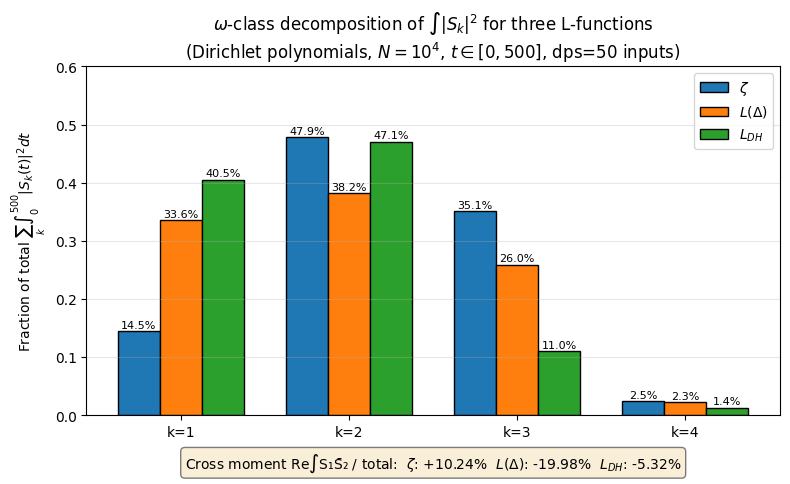

Figure saved


In [17]:

# The full off-diagonal also contributes significantly. That's a useful sanity check; off-diagonals shouldn't be ignored.
# Our hypothesis test is about the diagonal class decomposition only (per problem statement: "compute the diagonal moments ∫|S_k|² dt").

# Final figure: bar chart of fractions per class for the three L-functions, plus cross fraction
import matplotlib.pyplot as plt

L_list = ['zeta', 'Delta', 'LDH']
labels = [r'$\zeta$', r'$L(\Delta)$', r'$L_{DH}$']
ks = [1,2,3,4]
fracs = np.array([[out[L][f'frac_{k}'] for k in ks] for L in L_list]) # shape (3,4)
cross_rel = np.array([out[L]['rel_cross12'] for L in L_list])

fig, ax = plt.subplots(1,1, figsize=(8,5))
x = np.arange(len(ks))
width = 0.25
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, L in enumerate(L_list):
 bars = ax.bar(x + (i-1)*width, fracs[i], width, label=labels[i], color=colors[i], edgecolor='black')
 # annotate
 for j, b in enumerate(bars):
 ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
 f'{fracs[i,j]*100:.1f}%', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in ks])
ax.set_ylabel(r'Fraction of total $\sum_k \int_0^{500} |S_k(t)|^2 dt$')
ax.set_title(r'$\omega$-class decomposition of $\int |S_k|^2$ for three L-functions'
 '\n'+r'(Dirichlet polynomials, $N=10^4$, $t\in[0,500]$, dps=50 inputs)')
ax.legend(loc='upper right')
ax.set_ylim(0, 0.6)
ax.grid(alpha=0.3, axis='y')

# Add cross-term annotation below
txt = "Cross moment Re∫S₁S̄₂ / total: " + \
 " ".join([f"{labels[i]}: {cross_rel[i]*100:+.2f}%" for i in range(3)])
ax.text(0.5, -0.15, txt, transform=ax.transAxes, ha='center', fontsize=10,
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/workspace/446da375-0a72-426c-9359-fa04494d2691/omega_class_decomposition.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved")
